# Import library

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

%matplotlib inline

In [2]:
# data = "../dataset_collection/roboflow/object_detection/object_detection_all_class_10k_images/data.yaml"
# data = "../dataset_collection/roboflow/object_detection/object_detection_all_class/data.yaml"
data = "../dataset_collection/roboflow/k-shot/object_detection_all_class/40-shot.yaml"

# Normal shot fine tuning

In [3]:
# Menggunakan best model normal-shot yaitu size small 40k
model_normal =  YOLO("best_model/normal-small-40k/best.pt")
validation_model_normal = model_normal.val(data=data,
imgsz=640,
project="results",
name="model_normal",
split="train",
exist_ok=True)

csv_filename = "results/model_normal/validation-metrics.csv"
os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
with open(csv_filename, "w") as f:
    f.write(validation_model_normal.to_csv())

Ultralytics 8.3.243  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLOv12s summary (fused): 159 layers, 9,232,041 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 696.3220.1 MB/s, size: 779.7 KB)
val: Scanning C:\Users\abiyamf\Documents\Code Program\Thesis\dataset_collection\roboflow\k-shot\object_detection_all_class\40-shot\labels.cache... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 175.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.1it/s 1.9s0.2ss
                   all        120        264      0.963      0.903      0.968      0.885
    frog-eye-leaf-spot         40         60      0.964        0.9      0.975       0.89
               healthy         40        153      0.962      0.821      0.935      0.801
                  rust         40         51      0.962      0.987      0.995      0.963
Speed: 1.0ms preproce

# Few-shot fine tuning

In [4]:
# Menggunakan best model few-shot yaitu size medium 40k
model_few_shot=YOLO("best_model/few-shot-medium-40k/best.pt")
validation_model_few_shot = model_few_shot.val(data=data,
imgsz=640,
project="results",
name="model_few_shot",
split="train",
exist_ok=True)

csv_filename = "results/model_few_shot/validation-metrics.csv"
os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
with open(csv_filename, "w") as f:
    f.write(validation_model_few_shot.to_csv())

Ultralytics 8.3.243  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLOv12m summary (fused): 169 layers, 20,107,225 parameters, 0 gradients, 67.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3108.31073.9 MB/s, size: 748.9 KB)
val: Scanning C:\Users\abiyamf\Documents\Code Program\Thesis\dataset_collection\roboflow\k-shot\object_detection_all_class\40-shot\labels.cache... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.4it/s 2.3s0.2ss
                   all        120        264      0.921      0.938      0.979      0.959
    frog-eye-leaf-spot         40         60      0.931      0.833      0.958      0.939
               healthy         40        153      0.961          1      0.995      0.971
                  rust         40         51      0.871       0.98      0.983      0.967
Speed: 0.8ms preprocess, 6.8

# Comparison

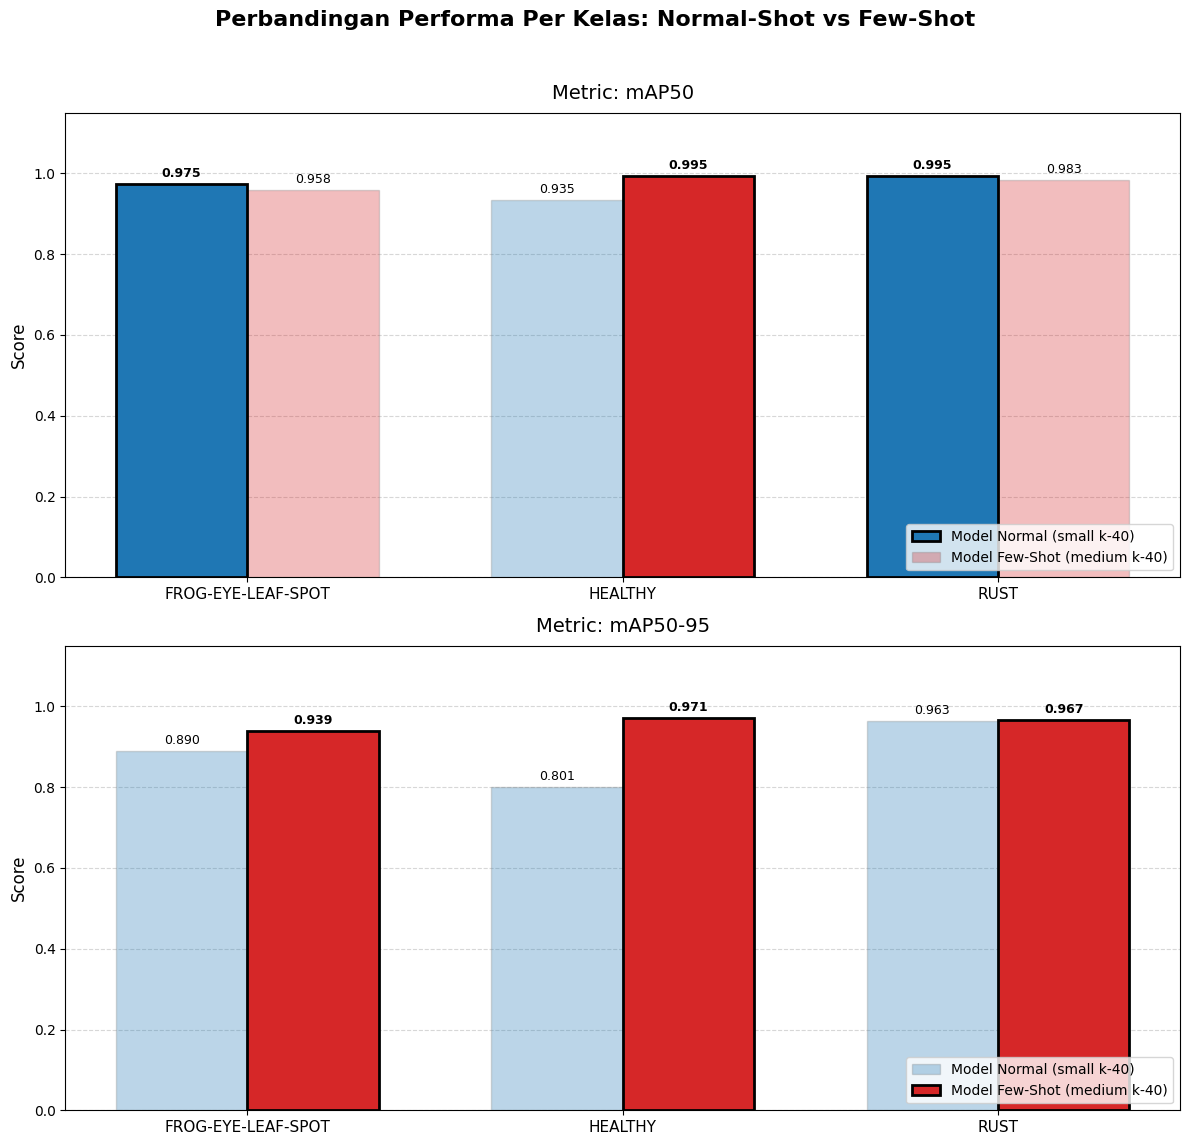

In [5]:
# --- 1. KONFIGURASI FILE ---
# Pastikan path ini benar
path_normal = "results/model_normal/validation-metrics.csv"
path_fewshot = "results/model_few_shot/validation-metrics.csv"

# Label untuk Legenda
MODEL_A_NAME = "Model Normal (small k-40)"
MODEL_B_NAME = "Model Few-Shot (medium k-40)"

# Warna
COLOR_A = "#1f77b4" # Biru
COLOR_B = "#d62728" # Merah

# --- 2. FUNGSI LOAD DATA ---
def load_data(csv_path):
    if not os.path.exists(csv_path):
        print(f"[ERROR] File tidak ditemukan: {csv_path}")
        return None
    
    try:
        df = pd.read_csv(csv_path)
        # Bersihkan spasi di nama kolom (Ultralytics sering ada spasi di header)
        df.columns = [c.strip() for c in df.columns]
        
        # Pastikan kolom Class ada
        if 'Class' not in df.columns:
            # Coba cari kolom pertama jika nama 'Class' berbeda
            df.rename(columns={df.columns[0]: 'Class'}, inplace=True)
            
        # Set Class sebagai Index agar mudah dicocokkan
        df.set_index('Class', inplace=True)
        return df
    except Exception as e:
        print(f"[ERROR] Gagal membaca {csv_path}: {e}")
        return None

# --- PERBAIKAN DI SINI ---
# Sebelumnya: df_10k = load_data(path_10k)  <-- Salah variabel path
# Sekarang:
df_normal = load_data(path_normal) 
df_fewshot = load_data(path_fewshot)

# --- 3. VISUALISASI ---
if df_normal is not None and df_fewshot is not None:
    
    # Ambil daftar kelas (intersect dari kedua file agar aman)
    classes = [cls for cls in df_normal.index if cls in df_fewshot.index]
    
    # Filter agar baris 'all' (rata-rata) ditaruh paling akhir
    if 'all' in classes:
        classes.remove('all')
        classes.append('all') 

    metrics = ["mAP50", "mAP50-95"]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 12))
    fig.suptitle("Perbandingan Performa Per Kelas: Normal-Shot vs Few-Shot", fontsize=16, fontweight='bold')
    
    x = np.arange(len(classes))
    bar_width = 0.35

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Data untuk plot (Gunakan df_normal)
        vals_a = [df_normal.loc[c, metric] for c in classes]
        vals_b = [df_fewshot.loc[c, metric] for c in classes]
        
        # Loop per kelas untuk menentukan pemenang
        for i, cls_name in enumerate(classes):
            val_a = vals_a[i]
            val_b = vals_b[i]
            
            # Tentukan max value di kelas ini
            max_val = max(val_a, val_b)
            
            # --- Plot Bar Model A (Normal) ---
            is_best_a = (val_a >= val_b)
            style_a = {
                'alpha': 1.0 if is_best_a else 0.3,
                'edgecolor': 'black' if is_best_a else 'gray',
                'linewidth': 2.0 if is_best_a else 1.0,
                'zorder': 5 if is_best_a else 3
            }
            bar_a = ax.bar(x[i] - bar_width/2, val_a, bar_width, label=MODEL_A_NAME if i == 0 else "", color=COLOR_A, **style_a)
            
            # Anotasi Nilai A
            ax.text(bar_a[0].get_x() + bar_width/2, val_a + 0.01, f"{val_a:.3f}", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold' if is_best_a else 'normal')

            # --- Plot Bar Model B (Few-Shot) ---
            is_best_b = (val_b > val_a)
            style_b = {
                'alpha': 1.0 if is_best_b else 0.3,
                'edgecolor': 'black' if is_best_b else 'gray',
                'linewidth': 2.0 if is_best_b else 1.0,
                'zorder': 5 if is_best_b else 3
            }
            bar_b = ax.bar(x[i] + bar_width/2, val_b, bar_width, label=MODEL_B_NAME if i == 0 else "", color=COLOR_B, **style_b)
            
            # Anotasi Nilai B
            ax.text(bar_b[0].get_x() + bar_width/2, val_b + 0.01, f"{val_b:.3f}", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold' if is_best_b else 'normal')

        # Kosmetik Grafik
        ax.set_title(f"Metric: {metric}", fontsize=14, pad=10)
        ax.set_ylabel("Score", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels([c.upper() for c in classes], fontsize=11, fontweight='medium')
        ax.set_ylim(0, 1.15) 
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        ax.legend(loc='lower right', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

else:
    print("Gagal memuat data. Periksa path file CSV Anda.")